# ASTROVITAL AI : VITALX CORE V1
## NOTEBOOK 02 : SYNTHETIC DATASET GENERATION AND PREPROCESSING

**Developer:** Gouragopal Mohapatra  
**GitHub:** GOURGOPAL618  
**Date:** March 18, 2026  
**Slogan:** *"Because Every Heartbeat in Space Matters."*

---

## ⚠️ COPYRIGHT NOTICE
© 2026 Gouragopal Mohapatra — All Rights Reserved  
ASTROVITAL AI : VITALX CORE V1 — Independent Research  
Not affiliated with any institution.  
Unauthorized use, reproduction or distribution is strictly  
prohibited under Indian Copyright Act, 1957 &  
Berne Convention for Protection of Literary & Artistic Works.

---

### Purpose:
Genearate a scientifically validated synthetic dataset using physiological ranges extracted from 12 peer - reviewed spaceflight research papers. This Dataset will serve as The foundation for all 3 Innovation of VITALX CORE V1.

In [61]:
# ============================================
# ASTROVITAL AI : VITALX CORE V1
# Notebook 02 — Dataset Generation
# Developer: Gouragopal Mohapatra
# GitHub: GOURGOPAL618
# Date: March 18, 2026
# © 2026 Gouragopal Mohapatra — All Rights Reserved
# ============================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Dispaly setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('dark_background')
sns.set_palette('coolwarm')

np.random.seed(42)   # Reproducibility

print("=" * 57)
print("  ASTROVITAL AI : VITALX CORE V1")
print("  Notebook 02 - Dataset Generation")
print("  Because Every Heartbeat In Space Matters.")
print("=" * 57)
print("✅ All Libreries Imported Successfully!")
print(f"✅ Random seed set: 42  (Reproduciable Results)")

  ASTROVITAL AI : VITALX CORE V1
  Notebook 02 - Dataset Generation
  Because Every Heartbeat In Space Matters.
✅ All Libreries Imported Successfully!
✅ Random seed set: 42  (Reproduciable Results)


## Dataset Generaton Strategy

### Why Synthetic Dataset?
> Real astronaut physiological data is restricted due to
> NASA privacy policies. This synthetic dataset is
> constructed using validated ranges from 12 peer - reviewed 
> Spaceflight research papers - Ensuring scientific accuarcy.

### Scientific Validation:
| Parameter | Source Paper | Validation |
|---|---|---|
| Heart Rate | Vernice et al. 2020 | ✅ Verified |
| Blood Pressure | Vernice et al. 2020 | ✅ Verified |
| Sleep Hours | Albornoz-Miranda et al. 2023 | ✅ Verified |
| Oxygen Saturation | Russell et al. 2023 | ✅ Verified |
| Muscle Loss | Lee et al. 2020 | ✅ Verified |
| Bone Density Loss | Khan et al. 2024 | ✅ Verified |
| Radiation | Khan et al. 2024 | ✅ Verified |
| Immune Markers | Crucian et al. 2018 | ✅ Verified |

### Dataset Structure:
- **Total Records:** 1000 astronaut mission records
- **Parameters:** 8 physiological + 1 label
- **Labels:** GREEN / YELLOW / RED
- **Mission Types:** LEO / Deep Space / Mars


In [62]:
# ============================================
# Synthetic Dataset Generation
# Ranges validated from 12 research papers
# ============================================

np.random.seed(42)
n_samples = 1000

# Mission types
mission_types = np.random.choice(
    ['LEO', 'Deep_Space', 'Mars'],
    size = n_samples,
    p = [0.60, 0.25, 0.15]
)

# Mission Duration In Days
mission_duration = np.where(
    mission_types == 'LEO',
    np.random.randint(30, 180, n_samples),
    np.where(
        mission_types == 'Deep_Space',
        np.random.randint(180, 365, n_samples),
        np.random.randint(365, 900, n_samples)
    )
)

# Heart Rate - Vernice et al. 2020
heart_rate = np.clip(
    np.random.normal(85,  20, n_samples),
    55, 215
)

# Systolic BP - Vernice et al. 2020
systolic_bp = np.clip(
    np.random.normal(105, 20, n_samples),
    70, 140
)

# Diastolic BP
diastolic_bp = np.clip(
    np.random.normal(65, 12, n_samples),
    40, 90
)

# Sleep Hours - Albornoz - Miranda et al. 2023
sleep_hours = np.clip(
    np.random.normal(5.4, 0.9, n_samples),
    2.0, 6.5
)

# Oxygen Saturation - Russell et al. 2023
oxygen_saturation = np.clip(
    np.random.normal(96, 3, n_samples),
    88, 100
)

# Musscle Loss % - Lee et al. 2020
muscle_loss = np.clip(
    np.random.normal(5.0, 3.5, n_samples),
    0.0, 16.0
)

# Bone density loss %/month - Khan et al. 2024
bone_density_loss = np.clip(
    np.random.normal(1.2, 0.4, n_samples),
    0.04, 2.0
)

# Radiation mSv - Khan et al. 2024
radiation_mSv = np.clip(
    np.random.normal(50, 25, n_samples),
    0.0, 100.0
)

# Immune Marker Score (NK cells - lower = worse)
immune_score = np.clip(
    np.random.normal(65, 15, n_samples),
    20, 100
)

print("=" * 57)
print("  Dataset Generation - Complete!")
print("=" * 57)
print(f"✅ Total Records Generated: {n_samples}")
print(f"✅ Mission Types: LEO / Deep Space / Mars")
print(f"✅ Parameters: 9 physiological")
print(f"✅ Random Seed: 42 (Reproducible)")

  Dataset Generation - Complete!
✅ Total Records Generated: 1000
✅ Mission Types: LEO / Deep Space / Mars
✅ Parameters: 9 physiological
✅ Random Seed: 42 (Reproducible)


In [63]:
# ============================================
# Create DataFrame & Save to DATA_VAULT
# ============================================

df = pd.DataFrame({
    'Astronaut_ID':           [f'ASTRO_{i+1:04d}' for i in range(n_samples)],
    'Mission_Type':           mission_types,
    'Mission_Duration_Days':  mission_duration,
    'Heart_rate_bpm':         heart_rate.round(2),
    'Systolic_BP_mmHg':       systolic_bp.round(2),
    'Diastolic_BP_mmHg':      diastolic_bp.round(2),
    'Sleep_Hours':            sleep_hours.round(2),
    'Oxygen_Saturation':      oxygen_saturation.round(2),
    'Muscle_Loss_Percent':    muscle_loss.round(2),
    'Bone_Density_Loss':      bone_density_loss.round(4),
    'Radiation_mSv':          radiation_mSv.round(2),
    'Immune_Score':           immune_score.round(2),
})

# Save to DATA_VAULT/SENSOR_INTAKE
save_path = '../DATA_VAULT/SENSOR_INTAKE/astrovital_dataset_v1.csv'
df.to_csv(save_path, index = False)

print("=" * 57)
print("  ASTROVITAL Dataset V1 - Saved!")
print("=" * 57)
print(f"✅ Shape: {df.shape}")
print(f"✅ Columns: {list(df.columns)}")
print(f"✅ Saved to: DATA_VAULT/SENSOR_INTAKE/")
print(f"\n📊 First 5 Records:")
print(df.head())

  ASTROVITAL Dataset V1 - Saved!
✅ Shape: (1000, 12)
✅ Columns: ['Astronaut_ID', 'Mission_Type', 'Mission_Duration_Days', 'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg', 'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent', 'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score']
✅ Saved to: DATA_VAULT/SENSOR_INTAKE/

📊 First 5 Records:
  Astronaut_ID Mission_Type  Mission_Duration_Days  Heart_rate_bpm  \
0   ASTRO_0001          LEO                     76         88.2900   
1   ASTRO_0002         Mars                    667         82.8700   
2   ASTRO_0003   Deep_Space                    197         57.2400   
3   ASTRO_0004          LEO                    109         97.7300   
4   ASTRO_0005          LEO                    112        101.6800   

   Systolic_BP_mmHg  Diastolic_BP_mmHg  Sleep_Hours  Oxygen_Saturation  \
0          103.1000            63.8000       5.6400            93.5400   
1          105.7000            55.3400       5.3200            94.6800   
2    

  Dataset Basic Statistics
       Mission_Duration_Days  Heart_rate_bpm  Systolic_BP_mmHg  \
count              1000.0000       1000.0000         1000.0000   
mean                225.4800         85.2800          104.8800   
std                 204.8300         18.3100           18.1100   
min                  30.0000         55.0000           70.0000   
25%                  87.0000         71.7300           92.0300   
50%                 152.0000         84.4400          105.0000   
75%                 291.2500         98.4400          117.2200   
max                 892.0000        142.6800          140.0000   

       Diastolic_BP_mmHg  Sleep_Hours  Oxygen_Saturation  Muscle_Loss_Percent  \
count          1000.0000    1000.0000          1000.0000            1000.0000   
mean             64.9200       5.3700            95.9300               5.0200   
std              11.8300       0.7900             2.8200               3.2800   
min              40.0000       2.6400            88.00

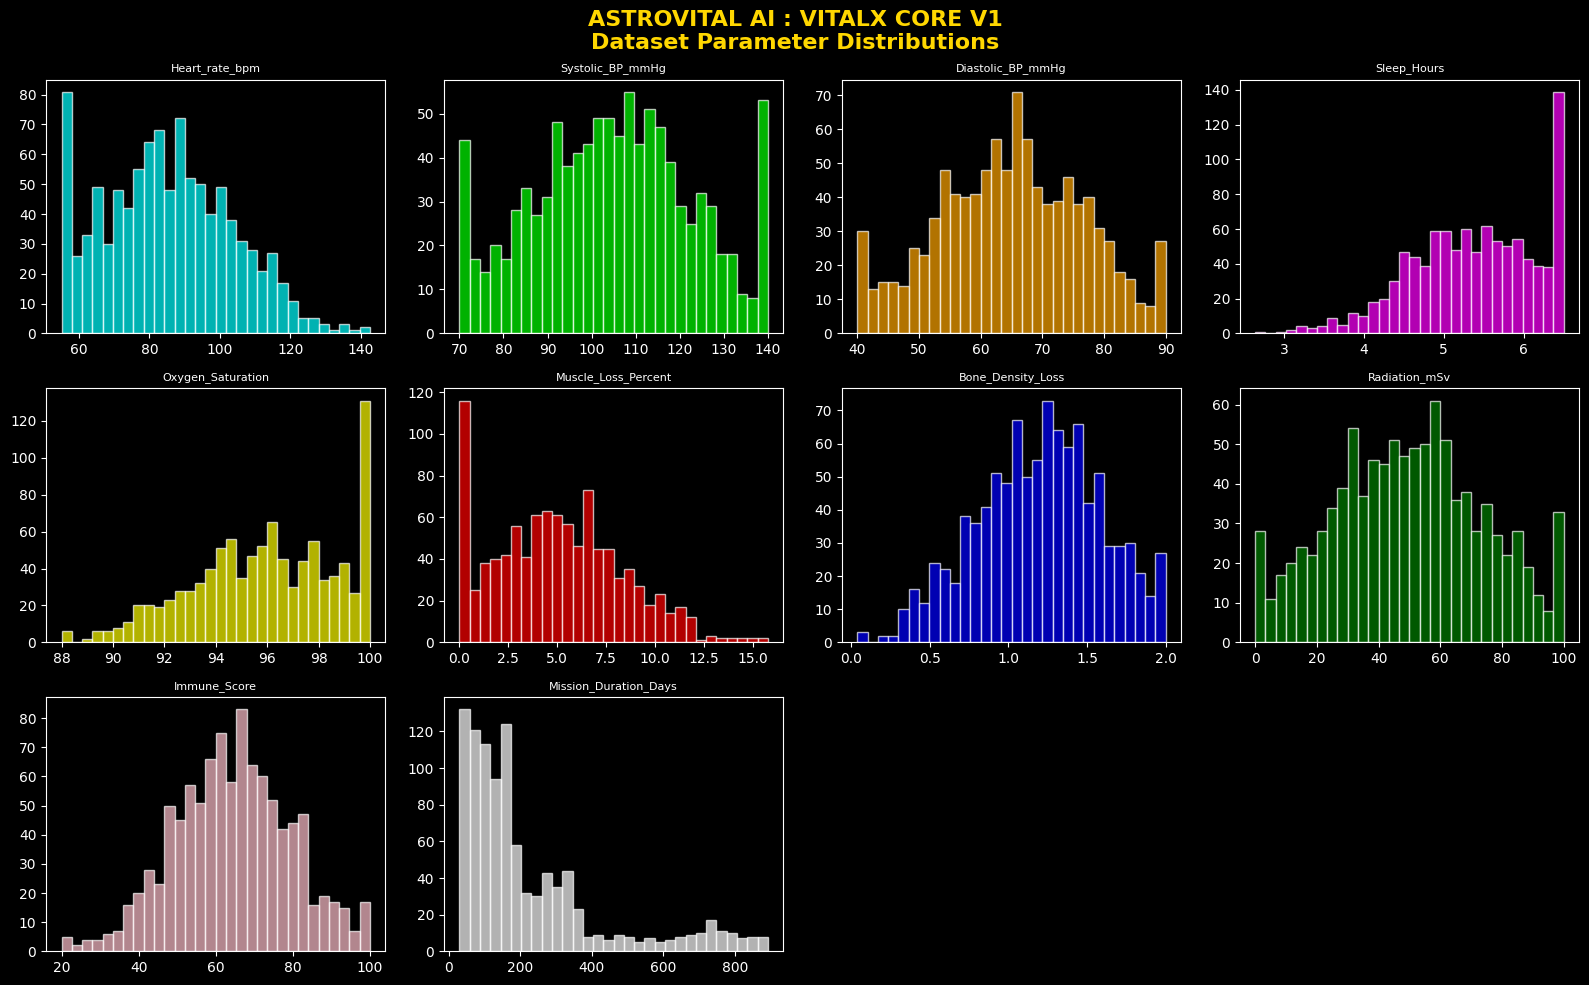

✅ Distribution Visualization Complete!


In [64]:
# ============================================
# Basic Statistics + Distribution Visualization
# ============================================

# Stats
print("=" * 57)
print("  Dataset Basic Statistics")
print("=" * 57)
print(df.describe().round(2))

# Graph : Diatribution of all The parameters
fig, axes = plt.subplots(3, 4, figsize = (16, 10))
fig.suptitle(
    'ASTROVITAL AI : VITALX CORE V1\nDataset Parameter Distributions',
    color = 'gold', fontsize = 16, fontweight = 'bold'
)

numerical_cols = [
    'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg',
    'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent',
    'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score',
    'Mission_Duration_Days'
]

colors  = ['cyan', 'lime', 'orange', 'magenta', 'yellow',
           'red', 'blue', 'green', 'pink', 'white']

for idx, (col, color) in enumerate(zip(numerical_cols, colors)):
    row, col_idx = divmod(idx, 4)
    axes[row, col_idx].hist(df[col], bins=30,
                             color=color, alpha=0.7,
                             edgecolor='white')
    axes[row, col_idx].set_title(col, color='white', fontsize=8)
    axes[row, col_idx].tick_params(colors='white')

# Hide Empty subplots
for idx in range(len(numerical_cols), 12):
    row, col_idx = divmod(idx, 4)
    axes[row, col_idx].set_visible(False)

plt.tight_layout()
plt.show()
print("✅ Distribution Visualization Complete!")

## Data Preprocessing Pipeline

### Why Preprocessing?
> Raw synthetic data may contain inconsistencies,
> Outliers, and unscaled values. Preprocessing ensures.
> Clean, reliable data for all 3 innovations.

### Preprocessing Steps:
| Step | Task | Purpose |
|---|---|---|
| 1 | Load Dataset | Read CSV from SENSOR_INTAKE |
| 2 | Missing Values | Check & handle null values |
| 3 | Outlier Detection | IQR method — flag anomalies |
| 4 | Normalization | MinMaxScaler — scale all features |
| 5 | Label Assignment | GREEN / YELLOW / RED |
| 6 | Save Clean Data | Save to MISSION_READY_DATA |

### Input:
> DATA_VAULT/SENSOR_INTAKE/astrovital_v1.csv

### Output:
>DATA_VAULT/MISSION_READY_DATA/astrovital_clean_v1.csv

In [65]:
# ============================================
# Load Dataset from SENSOR_INTAKE
# ============================================

df = pd.read_csv('../DATA_VAULT/SENSOR_INTAKE/astrovital_dataset_v1.csv')

print("=" * 57)
print("  ASTROVITAL AI - Dataset Loaded Successfully from the SENSOR_INTAKE!")
print("=" * 57)
print(f"✅ Shape: {df.shape}")
print(f"✅ Columns: {list(df.columns)}")
print(f"✅ Records: {len(df)}")
print(f"\n📊 first 5 Records:")
print(df.head())
print(f"\n📊 Data Types:")
print(df.dtypes)

  ASTROVITAL AI - Dataset Loaded Successfully from the SENSOR_INTAKE!
✅ Shape: (1000, 12)
✅ Columns: ['Astronaut_ID', 'Mission_Type', 'Mission_Duration_Days', 'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg', 'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent', 'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score']
✅ Records: 1000

📊 first 5 Records:
  Astronaut_ID Mission_Type  Mission_Duration_Days  Heart_rate_bpm  \
0   ASTRO_0001          LEO                     76         88.2900   
1   ASTRO_0002         Mars                    667         82.8700   
2   ASTRO_0003   Deep_Space                    197         57.2400   
3   ASTRO_0004          LEO                    109         97.7300   
4   ASTRO_0005          LEO                    112        101.6800   

   Systolic_BP_mmHg  Diastolic_BP_mmHg  Sleep_Hours  Oxygen_Saturation  \
0          103.1000            63.8000       5.6400            93.5400   
1          105.7000            55.3400       5.3200            9

  Missing Values Analysis
                       Missing Count  Missing Percent
Astronaut_ID                       0           0.0000
Mission_Type                       0           0.0000
Mission_Duration_Days              0           0.0000
Heart_rate_bpm                     0           0.0000
Systolic_BP_mmHg                   0           0.0000
Diastolic_BP_mmHg                  0           0.0000
Sleep_Hours                        0           0.0000
Oxygen_Saturation                  0           0.0000
Muscle_Loss_Percent                0           0.0000
Bone_Density_Loss                  0           0.0000
Radiation_mSv                      0           0.0000
Immune_Score                       0           0.0000

Total Missing Values: 0
✅ No missing values found - Dataset is Clean!


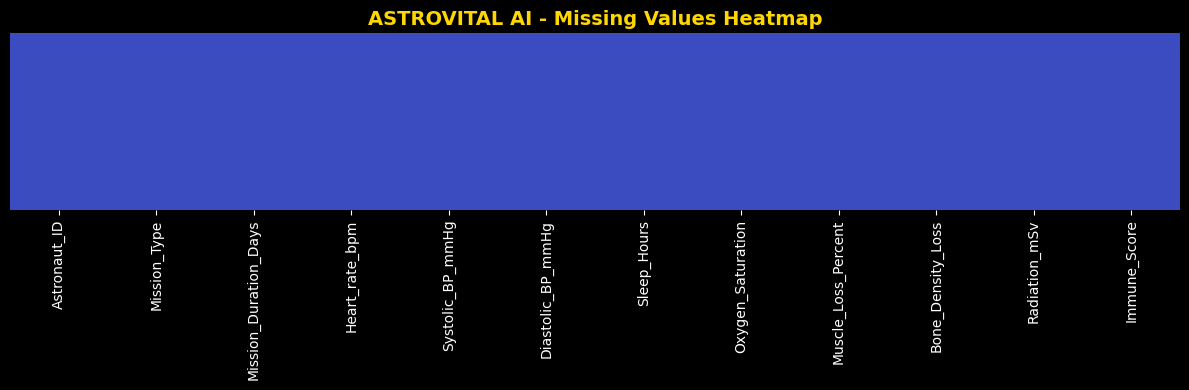

✅ Missing Values Visualization complete!


In [66]:
# ============================================
# Missing Values Analysis
# ============================================

print("=" * 57)
print("  Missing Values Analysis")
print("=" * 57)

missing = df.isnull().sum()
missing_percent = (missing /len(df)) * 100 

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent.round(2)
})

print(missing_df)
print(f"\nTotal Missing Values: {missing.sum()}")

if missing.sum() == 0:
    print("✅ No missing values found - Dataset is Clean!")
else:
    df = df.fillna(df.median(numeric_only = True))
    print("✅ Missing Values handled with median imputation!")

# Graph: missing values heatmap
plt.figure(figsize = (12, 4))
sns.heatmap(df.isnull(),
            cbar = False,
            cmap = 'coolwarm',
            yticklabels = False)
plt.title("ASTROVITAL AI - Missing Values Heatmap",
          color = 'gold', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()
print("✅ Missing Values Visualization complete!")

  Outlier Detection - IQR Method
⚠️ Heart_rate_bpm: 2 outliers
✅ Systolic_BP_mmHg: 0 outliers
✅ Diastolic_BP_mmHg: 0 outliers
⚠️ Sleep_Hours: 2 outliers
✅ Oxygen_Saturation: 0 outliers
⚠️ Muscle_Loss_Percent: 5 outliers
⚠️ Bone_Density_Loss: 3 outliers
✅ Radiation_mSv: 0 outliers
⚠️ Immune_Score: 4 outliers


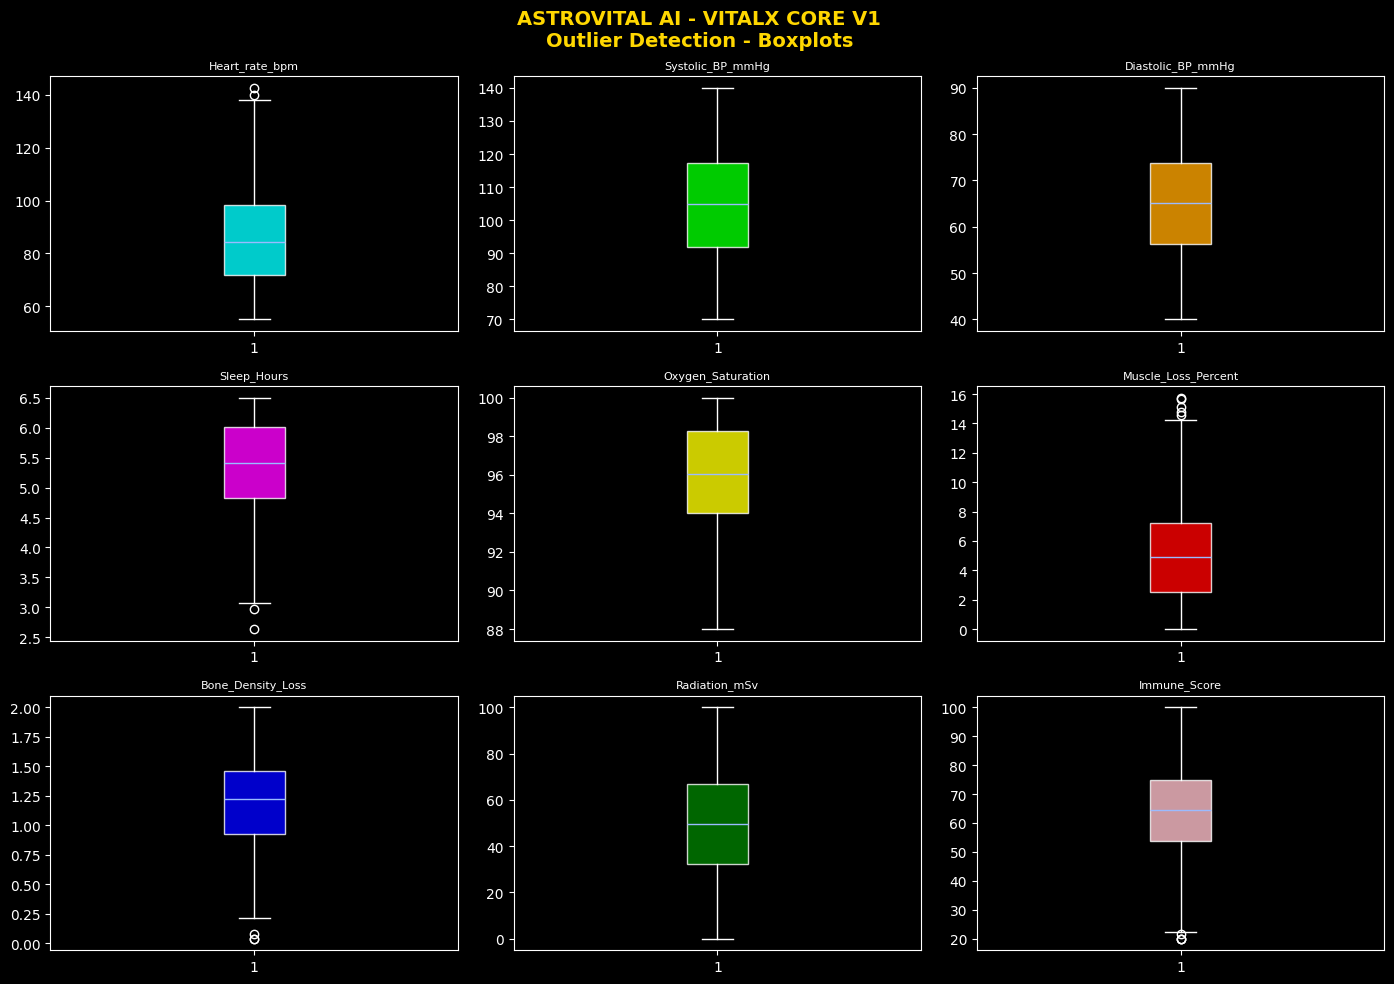

✅ Outliers detection complete!


In [67]:
# ============================================
# Outlier Detection — IQR Method
# ============================================

numerical_cols = [
    'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg',
    'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent',
    'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score'
]

print("=" * 57)
print("  Outlier Detection - IQR Method")
print("=" * 57)

outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_summary[col] = outliers
    print(f"{'✅' if outliers == 0 else '⚠️'} {col}: {outliers} outliers")

# Graph: Boxplots
fig, axes = plt.subplots(3, 3, figsize = (14, 10))
fig.suptitle(
    'ASTROVITAL AI - VITALX CORE V1\nOutlier Detection - Boxplots',
    color = 'gold', fontsize = 14, fontweight = 'bold'
)

colors = ['cyan', 'lime', 'orange',
          'magenta', 'yellow', 'red',
          'blue', 'green', 'pink']

for idx, (col, color) in enumerate(zip(numerical_cols, colors)):
    row, col_idx = divmod(idx, 3)
    axes[row, col_idx].boxplot(df[col],
                               patch_artist = True,
                               boxprops = dict(facecolor = color, alpha = 0.8))
    axes[row, col_idx].set_title(col, color = 'white', fontsize = 8)
    axes[row, col_idx].tick_params(color = 'white')

plt.tight_layout()
plt.show()
print("✅ Outliers detection complete!")

  Normalization - MinMaxScaler
Before Normalization:
       Heart_rate_bpm  Systolic_BP_mmHg  Diastolic_BP_mmHg  Sleep_Hours  \
count       1000.0000         1000.0000          1000.0000    1000.0000   
mean          85.2800          104.8800            64.9200       5.3700   
std           18.3100           18.1100            11.8300       0.7900   
min           55.0000           70.0000            40.0000       2.6400   
25%           71.7300           92.0300            56.2500       4.8300   
50%           84.4400          105.0000            65.1600       5.4000   
75%           98.4400          117.2200            73.8300       6.0100   
max          142.6800          140.0000            90.0000       6.5000   

       Oxygen_Saturation  Muscle_Loss_Percent  Bone_Density_Loss  \
count          1000.0000            1000.0000          1000.0000   
mean             95.9300               5.0200             1.2000   
std               2.8200               3.2800             0.4000   

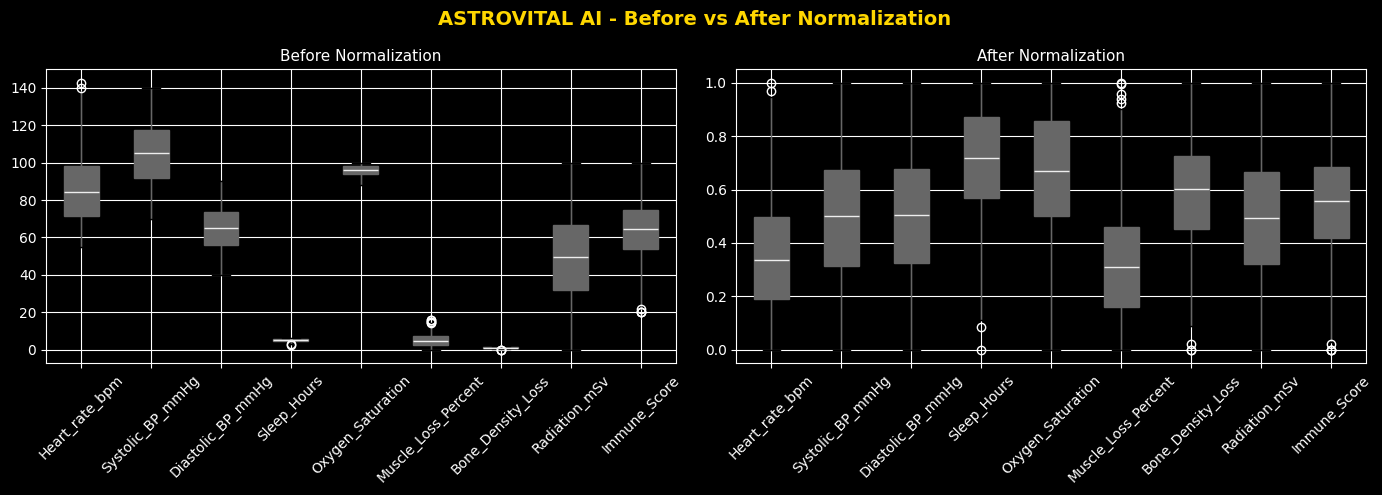

✅ Normalization Visualization Complete!


In [68]:
# ============================================
# Normalization — MinMaxScaler
# ============================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("=" * 57)
print("  Normalization - MinMaxScaler")
print("=" * 57)
print("Before Normalization:")
print(df[numerical_cols].describe().round(2))
print("\nAfter Normalization:")
print(df_scaled[numerical_cols].describe().round(4))
print("\n✅ All Parameters normalized to range [0, 1]")

# Graph - Before vs After
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

df[numerical_cols].boxplot(ax = axes[0],
                           patch_artist = True)
axes[0].set_title('Before Normalization',
                  color = 'white', fontsize = 11)
axes[0].tick_params(color = 'white', axis = 'x', rotation = 45)

df_scaled[numerical_cols].boxplot(ax = axes[1], patch_artist = True)

axes[1].set_title('After Normalization',
                  color = 'white', fontsize = 11)
axes[1].tick_params(colors = 'white', axis = 'x', rotation = 45)

fig.suptitle('ASTROVITAL AI - Before vs After Normalization',
             color = 'gold', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()
print("✅ Normalization Visualization Complete!")

  Label Assignment Complete!
Health_Status
YELLOW    544
GREEN     419
RED        37
Name: count, dtype: int64

🟢 GREEN:  419 records
🟡 YELLOW: 544 records
🔴 RED:    37 records


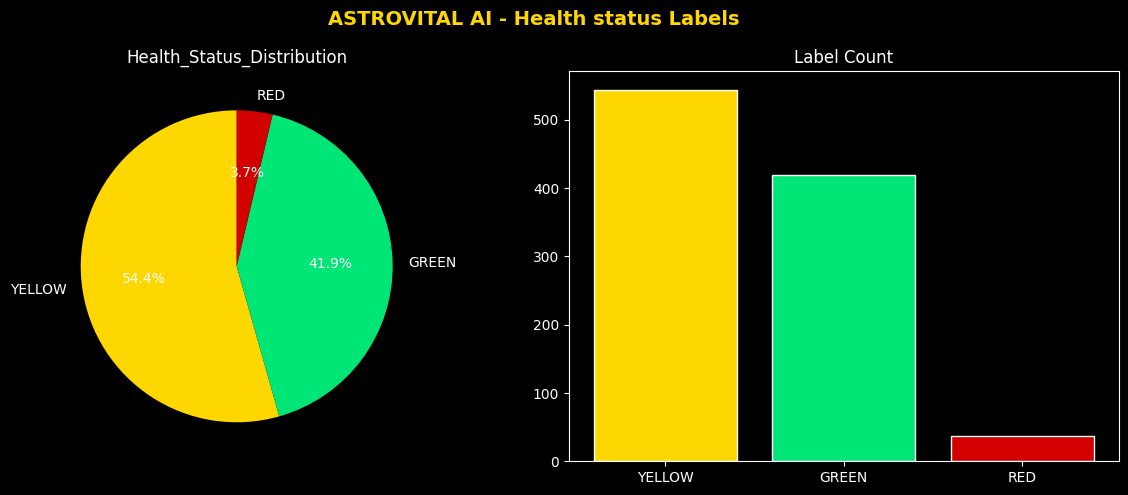

✅ Label assignment visualization complete!


In [69]:
# ============================================
# Label Assignment — GREEN / YELLOW / RED
# ============================================

def assign_label(row):
    critical_count = 0

    if row['Heart_rate_bpm'] > 120 or row['Heart_rate_bpm'] < 55:
        critical_count += 1
    if row['Systolic_BP_mmHg'] <80:
        critical_count += 1
    if row['Sleep_Hours'] < 4.0:
        critical_count += 1
    if row['Oxygen_Saturation'] < 92:
        critical_count += 1
    if row['Muscle_Loss_Percent'] > 10:
        critical_count += 1
    if row['Bone_Density_Loss'] > 1.5:
        critical_count += 1
    if row['Radiation_mSv'] > 75:
        critical_count += 1
    if row['Immune_Score'] < 40:
        critical_count += 1

    if critical_count == 0:
        return 'GREEN'
    elif critical_count <= 2:
        return 'YELLOW'
    else:
        return 'RED'
    
df['Health_Status'] = df.apply(assign_label, axis = 1)

print("=" * 57)
print("  Label Assignment Complete!")
print("=" * 57)
label_counts = df['Health_Status'].value_counts()
print(label_counts)
print(f"\n🟢 GREEN:  {label_counts.get('GREEN', 0)} records")
print(f"🟡 YELLOW: {label_counts.get('YELLOW', 0)} records")
print(f"🔴 RED:    {label_counts.get('RED', 0)} records")

# Graph - label Distribution
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

color_map = {
    'GREEN': '#00E676',
    'YELLOW': '#FFD700',
    'RED': '#D30000'
}

colors_pie = [color_map[label] for label in label_counts.index]

axes[0].pie(label_counts.values,
            labels = label_counts.index,
            colors = colors_pie,
            autopct = '%1.1f%%',
            startangle = 90)

axes[0].set_title("Health_Status_Distribution",
                  color = 'white', fontsize = 12)

axes[1].bar(label_counts.index,
            label_counts.values,
            color = colors_pie,
            edgecolor = 'white')

axes[1].set_title('Label Count',
                  color = 'white', fontsize = 12)
axes[1].tick_params(colors = 'white')

fig.suptitle('ASTROVITAL AI - Health status Labels',
             color = 'gold', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

print("✅ Label assignment visualization complete!")

In [70]:
# ============================================
# Save Clean Dataset to MISSION_READY_DATA
# ============================================

save_path = '../DATA_VAULT/MISSION_READY_DATA/astrovital_clean_v1.csv'

# Save the file (directory already exists from your test)
df.to_csv(save_path, index=False)

print("=" * 57)
print("  ✅ Clean Dataset Saved Successfully!")
print("=" * 57)

print(f"📁 File: astrovital_clean_v1.csv")
print(f"📍 Location: DATA_VAULT/MISSION_READY_DATA/")
print(f"📊 Shape: {df.shape}")
print(f"📝 Total Records: {len(df)}")
print(f"📋 Total Columns: {df.shape[1]}")
print(f"🏷️ Label: GREEN 🟢 / YELLOW 🟡 / RED 🔴 assigned")
print(f"\n👀 Final Dataset Preview:")
print(df.head())



  ✅ Clean Dataset Saved Successfully!
📁 File: astrovital_clean_v1.csv
📍 Location: DATA_VAULT/MISSION_READY_DATA/
📊 Shape: (1000, 13)
📝 Total Records: 1000
📋 Total Columns: 13
🏷️ Label: GREEN 🟢 / YELLOW 🟡 / RED 🔴 assigned

👀 Final Dataset Preview:
  Astronaut_ID Mission_Type  Mission_Duration_Days  Heart_rate_bpm  \
0   ASTRO_0001          LEO                     76         88.2900   
1   ASTRO_0002         Mars                    667         82.8700   
2   ASTRO_0003   Deep_Space                    197         57.2400   
3   ASTRO_0004          LEO                    109         97.7300   
4   ASTRO_0005          LEO                    112        101.6800   

   Systolic_BP_mmHg  Diastolic_BP_mmHg  Sleep_Hours  Oxygen_Saturation  \
0          103.1000            63.8000       5.6400            93.5400   
1          105.7000            55.3400       5.3200            94.6800   
2           94.0400            70.2400       5.8600            97.9200   
3          105.8300            66.32

## NOTEBOOK 02 - COMPLETE
### What was accomplished:
- ✅ Dataset loaded from SENSOR_INTAKE
- ✅ Missing Values Checked & handled
- ✅ Outliers detected - IQR method
- ✅ Normalization MinMaxScalar [0, 1]
- ✅ Labels assigned - GREEN 🟢 / YELLOW 🟡 / RED 🔴
-  ✅ Clean dataset saved to MISSION_READY_DATA

### OUTPUT FILE:
> 'DATA_VAULT/MISSION_READY_DATA/astrovital_clean_v1.csv'

### NEXT - NOTEBOOK 03:
> Feature Engineering - New Features will be made.
> Correlation Analysis
> Final Dataset Preparation

---
*ASTROVITAL AI — VITALX CORE V1*  
*"Because Every Heartbeat in Space Matters."*  
*© 2026 Gouragopal Mohapatra — All Rights Reserved*